Train shape: (58645, 13)
Test shape: (39098, 12)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status      

/var/folders/rs/ydzrh5cs02qcd0zs1ys96vj40000gn/T/ipykernel_15938/1247492960.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=train, palette='Blues')


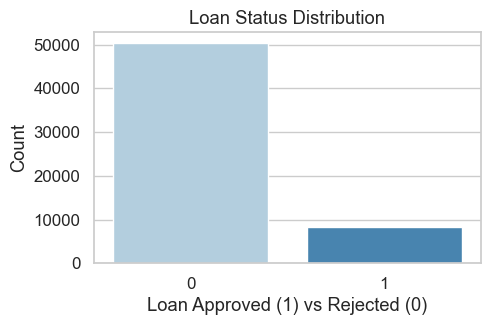

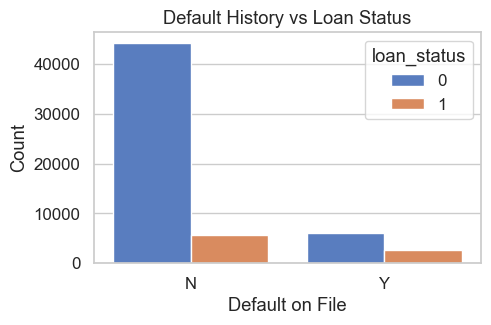

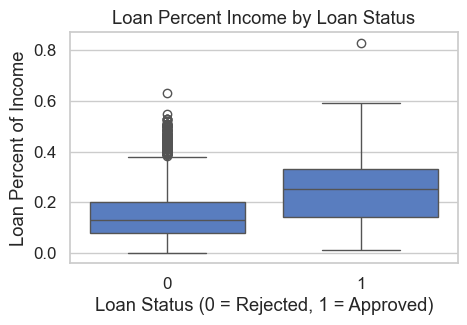

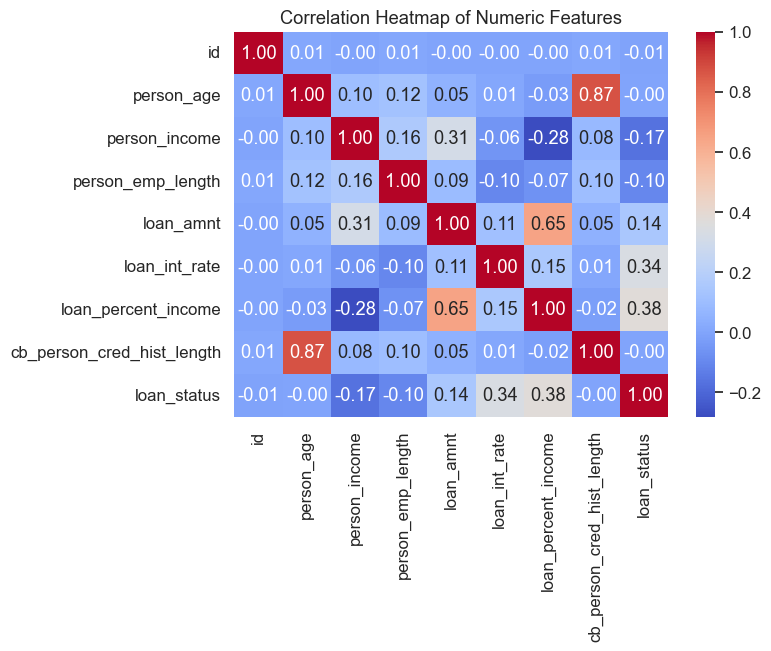


✅ Key Insights:
1. Dataset is highly imbalanced — majority of loans are rejected.
2. Applicants with past defaults are much less likely to be approved.
3. Approved applicants tend to have higher income-to-loan ratios.
4. Strong correlations found between income, loan amount, and loan_percent_income.
5. Several categorical variables (intent, ownership, grade) will need encoding.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', palette='muted', font_scale=1.1)

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

print("\n--- Dataset Info ---")
train.info()

print("\n--- Missing Values ---")
print(train.isnull().sum())

print("\n--- Target Distribution ---")
print(train['loan_status'].value_counts(normalize=True))

print("\n--- Summary Statistics ---")
print(train.describe())

plt.figure(figsize=(5,3))
sns.countplot(x='loan_status', data=train, palette='Blues')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Approved (1) vs Rejected (0)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(5,3))
sns.countplot(x='cb_person_default_on_file', hue='loan_status', data=train)
plt.title('Default History vs Loan Status')
plt.xlabel('Default on File')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(5,3))
sns.boxplot(x='loan_status', y='loan_percent_income', data=train)
plt.title('Loan Percent Income by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan Percent of Income')
plt.show()

numeric_features = train.select_dtypes(include=np.number)
plt.figure(figsize=(7,5))
sns.heatmap(numeric_features.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

print("""
✅ Key Insights:
1. Dataset is highly imbalanced — majority of loans are rejected.
2. Applicants with past defaults are much less likely to be approved.
3. Approved applicants tend to have higher income-to-loan ratios.
4. Strong correlations found between income, loan amount, and loan_percent_income.
5. Several categorical variables (intent, ownership, grade) will need encoding.
""")


Columns in train: ['id', 'person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']
Column `grade` not in DataFrame — available columns: ['id', 'person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']
Column `grade` not in DataFrame — available columns: ['id', 'person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']


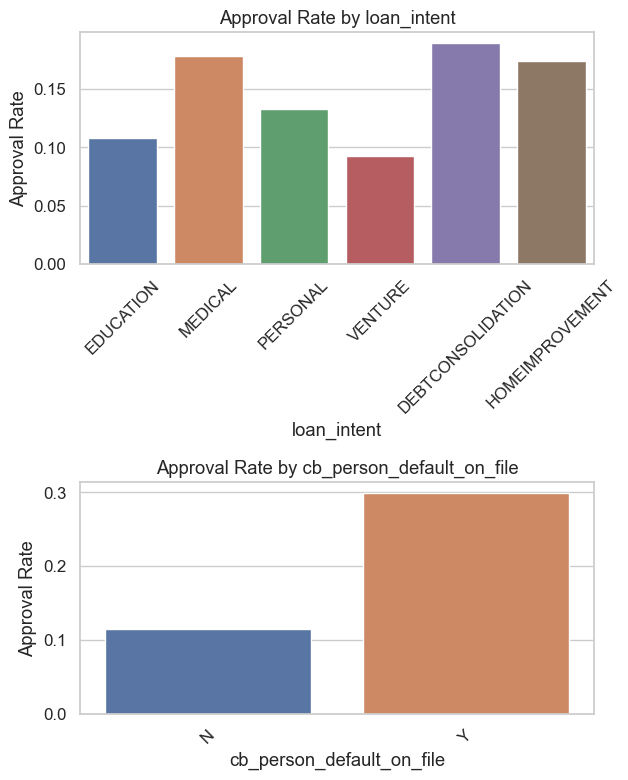

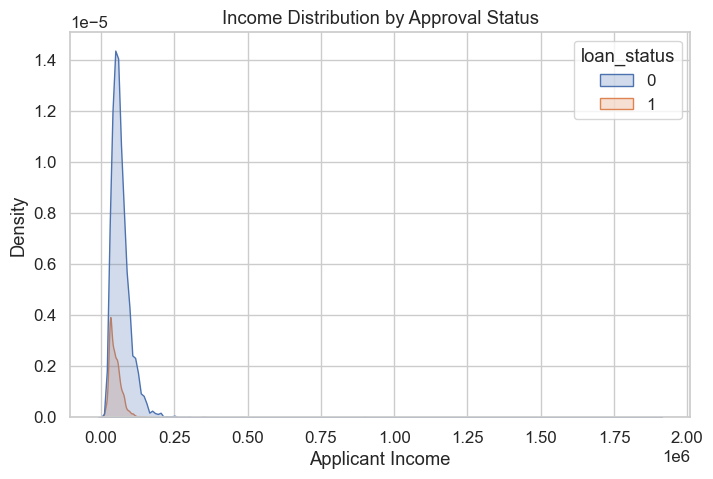

ValueError: Could not interpret value `loan_amount` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.1)

train = pd.read_csv("train.csv")
print("Columns in train:", train.columns.tolist())

categorical_cols = ['loan_intent', 'grade', 'cb_person_default_on_file']

plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_cols):
    if col not in train.columns:
        print(f"Column `{col}` not in DataFrame — available columns: {train.columns.tolist()}")
        continue
    plt.subplot(2, 2, i + 1)
    sns.barplot(
        x=col,
        y='loan_status',
        hue=col,
        data=train,
        estimator=np.mean,
        errorbar=None,
        legend=False
    )
    plt.xticks(rotation=45)
    plt.ylabel('Approval Rate')
    plt.title(f'Approval Rate by {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.kdeplot(data=train, x='person_income', hue='loan_status', fill=True)
plt.title('Income Distribution by Approval Status')
plt.xlabel('Applicant Income')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='person_income',
    y='loan_amount',
    hue='loan_status',
    data=train,
    alpha=0.6
)
plt.title('Loan Amount vs Income (colored by approval)')
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.show()

num_feats = ['person_income', 'loan_amount', 'loan_percent_income', 'cb_person_cred_hist_length']
available = [f for f in num_feats if f in train.columns]
if len(available) >= 2:
    sns.pairplot(train[available + ['loan_status']], hue='loan_status', diag_kind='kde', plot_kws={'alpha':0.5})
    plt.suptitle('Pairwise Plots of Key Numeric Features', y=1.02)
    plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='magma')
plt.title('Missing Value Pattern Across Dataset')
plt.show()

missing_frac = train.isnull().mean().sort_values(ascending=False)
print("\nMissing fraction per column:\n", missing_frac[missing_frac > 0])


Encoding categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Training Logistic Regression ...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression → Accuracy: 0.897, F1: 0.564, ROC-AUC: 0.887
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     10059
           1       0.71      0.47      0.56      1670

    accuracy                           0.90     11729
   macro avg       0.81      0.72      0.75     11729
weighted avg       0.89      0.90      0.89     11729

Confusion Matrix:
[[9737  322]
 [ 888  782]]

Training Random Forest ...
Random Forest → Accuracy: 0.949, F1: 0.795, ROC-AUC: 0.934
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10059
           1       0.93      0.69      0.79      1670

    accuracy                           0.95     11729
   macro avg       0.94      0.84      0.88     11729
weighted avg       0.95      0.95      0.95     11729

Confusion Matrix:
[[9972   87]
 [ 512 1158]]

Training XGBoost ...
Random Forest → Accuracy: 0.949, F1: 0.795, ROC-AUC: 0.934
              precision

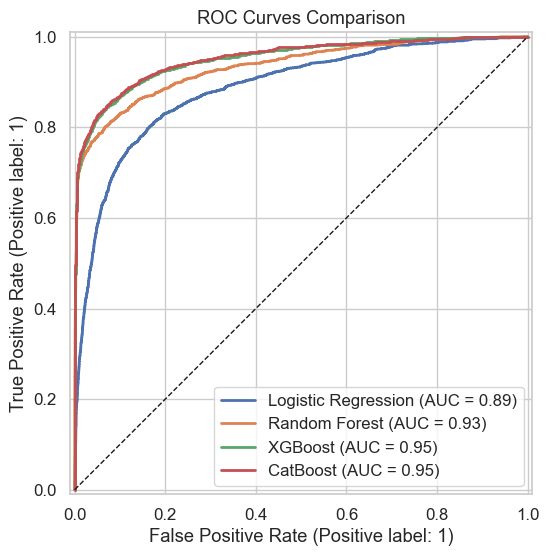

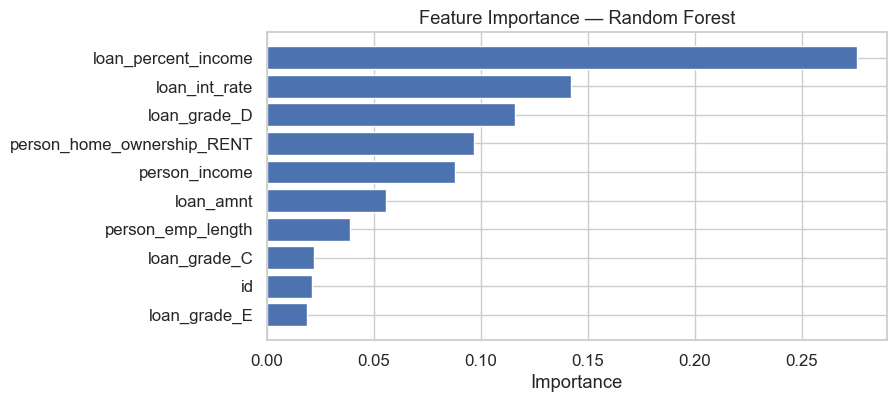

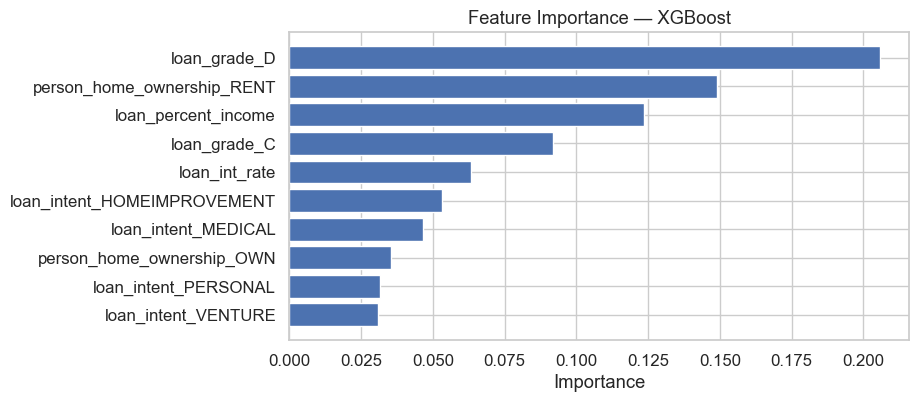

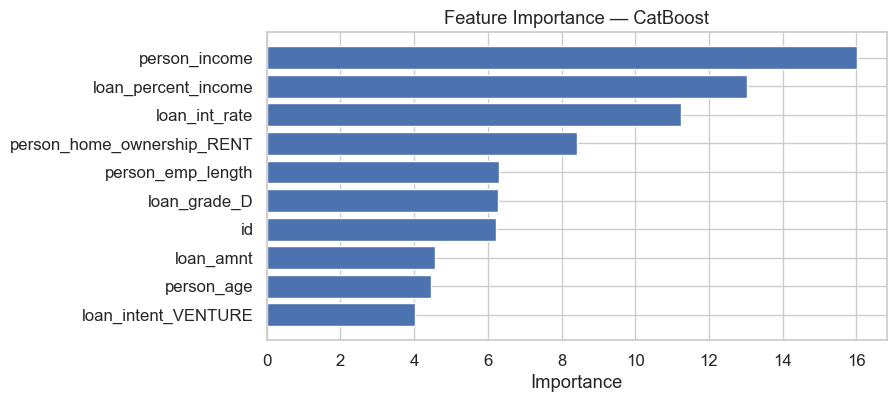

In [8]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

try:
    from catboost import CatBoostClassifier, Pool
    catboost_available = True
except ModuleNotFoundError:
    print("Warning: CatBoost is not installed — skipping CatBoost model.")
    catboost_available = False

df = pd.read_csv("train.csv")

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if cat_cols:
    print("Encoding categorical columns:", cat_cols)
    X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
numeric_cols = ["person_income", "loan_amount", "loan_percent_income", "cb_person_cred_hist_length"]
numeric_cols = [c for c in numeric_cols if c in X_train.columns]

if numeric_cols:
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver="lbfgs"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        learning_rate=0.1, max_depth=8, subsample=0.8,
        use_label_encoder=False, eval_metric="logloss"
    ),
}

if catboost_available:
    models["CatBoost"] = CatBoostClassifier(depth=8, learning_rate=0.1, iterations=500, verbose=False)

results = {}

for name, model in models.items():
    print(f"\nTraining {name} ...")
    if catboost_available and name == "CatBoost":
        model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)
    else:
        model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        "accuracy": acc,
        "f1": f1,
        "roc_auc": roc,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    
    print(f"{name} → Accuracy: {acc:.3f}, F1: {f1:.3f}, ROC-AUC: {roc:.3f}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res["y_prob"], name=name, lw=2, ax=plt.gca()
    )
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

def plot_importance(model, model_name, top_n=10):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feat_names = X_train.columns
        indices = np.argsort(importances)[::-1][:top_n]
        plt.figure(figsize=(8, 4))
        plt.title(f"Feature Importance — {model_name}")
        plt.barh(np.array(feat_names)[indices], importances[indices])
        plt.xlabel("Importance")
        plt.gca().invert_yaxis()
        plt.show()

for name, model in models.items():
    if name in ("Random Forest", "XGBoost"):
        plot_importance(model, name)
    if catboost_available and name == "CatBoost":
        imp = model.get_feature_importance()
        feat_names = X_train.columns
        imp_df = pd.DataFrame({"feature": feat_names, "importance": imp})
        imp_df = imp_df.sort_values(by="importance", ascending=False).head(10)
        plt.figure(figsize=(8, 4))
        plt.title("Feature Importance — CatBoost")
        plt.barh(imp_df["feature"], imp_df["importance"])
        plt.xlabel("Importance")
        plt.gca().invert_yaxis()
        plt.show()


Loaded train.csv shape: (58645, 13)
Columns: ['id', 'person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']
Train/test shapes: (46916, 12) (11729, 12)
Categorical columns detected and being one-hot encoded: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Numeric columns to scale: ['person_income', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_age', 'person_emp_length', 'loan_int_rate']

Training Logistic Regression ...
Logistic Regression → Accuracy: 0.912, F1: 0.631, ROC-AUC: 0.9033847009232356
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10059
           1       0.78      0.53      0.63      1670

    accuracy                           0.91     11729
   macro avg       0.85      0.75      0

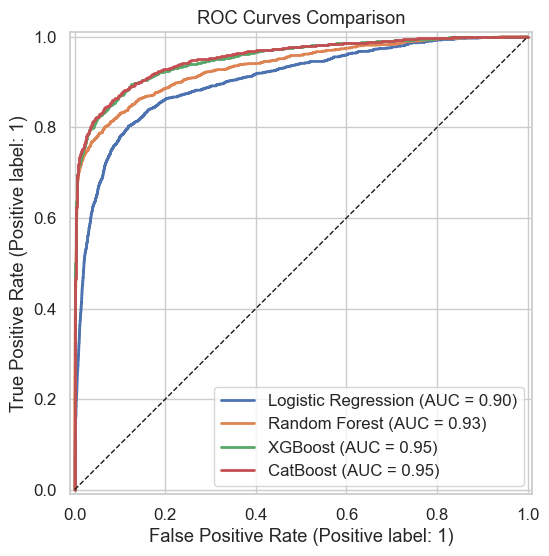

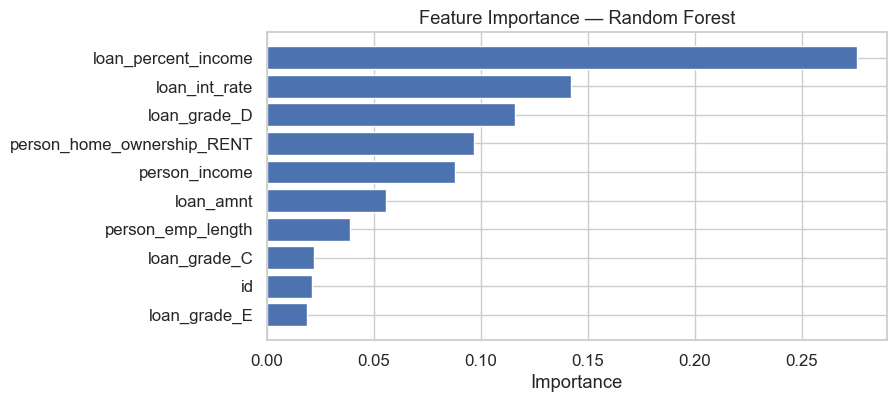

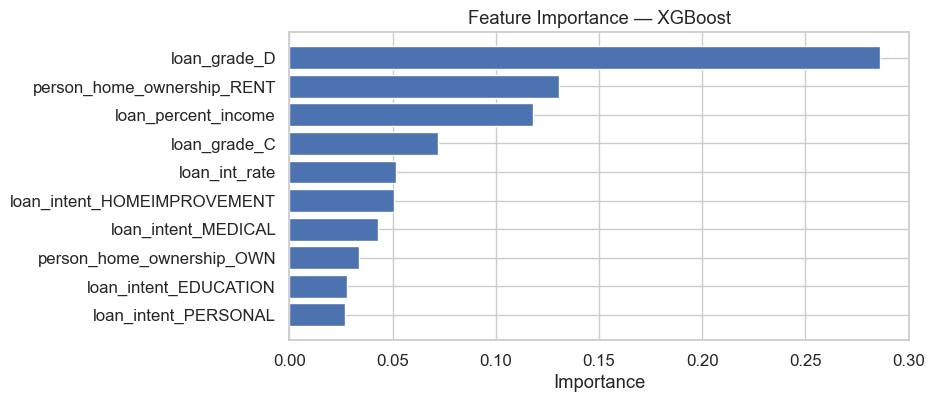

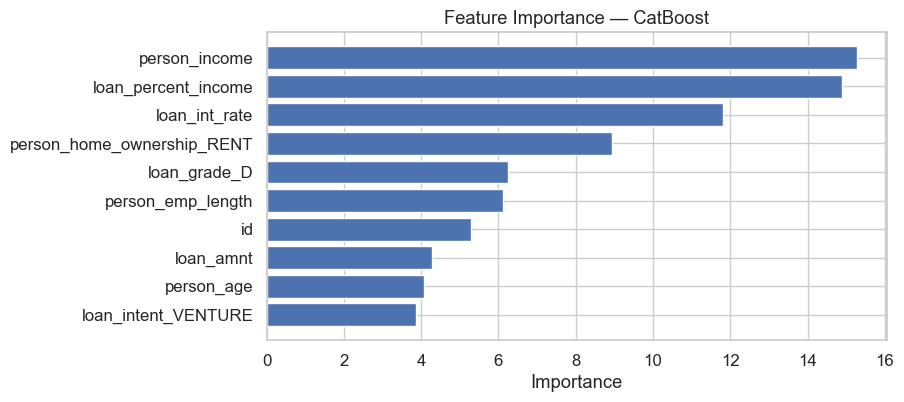

Saved model: models_checkpoint2/Logistic_Regression.joblib
Saved model: models_checkpoint2/Random_Forest.joblib
Saved model: models_checkpoint2/XGBoost.joblib
Saved model: models_checkpoint2/CatBoost.joblib

Model comparison:



,Model,Accuracy,F1,ROC-AUC
3,CatBoost,0.953108,0.816299,0.954333
2,XGBoost,0.950635,0.806030,0.952590
1,Random Forest,0.949015,0.794925,0.934424
0,Logistic Regression,0.911587,0.630566,0.903385


In [ ]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

try:
    from catboost import CatBoostClassifier, Pool
    catboost_available = True
except Exception:
    print("Warning: CatBoost is not installed — skipping CatBoost model.")
    catboost_available = False

df = pd.read_csv("train.csv")
print("Loaded train.csv shape:", df.shape)
print("Columns:", df.columns.tolist())

target_col = "loan_status"
if target_col not in df.columns:
    raise RuntimeError(f"Target column '{target_col}' not found in train.csv")

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train/test shapes:", X_train.shape, X_test.shape)

cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object" or X_train[c].dtype.name == 'category']
if cat_cols:
    print("Categorical columns detected and being one-hot encoded:", cat_cols)
    X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
else:
    print("No categorical columns detected.")

numeric_cols_candidate = ["person_income", "loan_amnt", "loan_percent_income", "cb_person_cred_hist_length", "person_age", "person_emp_length", "loan_int_rate"]
numeric_cols = [c for c in numeric_cols_candidate if c in X_train.columns]
print("Numeric columns to scale:", numeric_cols)

scaler = StandardScaler()
if numeric_cols:
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="lbfgs"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        learning_rate=0.1, max_depth=8, subsample=0.8,
        use_label_encoder=False, eval_metric="logloss", random_state=42
    ),
}

if catboost_available:
    models["CatBoost"] = CatBoostClassifier(depth=8, learning_rate=0.1, iterations=500, verbose=False, random_state=42)

results = {}

def get_proba_or_score(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.shape[1] >= 2:
            return proba[:, 1]
        else:
            return proba.ravel()
    if hasattr(model, "decision_function"):
        dec = model.decision_function(X)
        if dec.ndim == 1:
            from scipy.special import expit
            return expit(dec)
        else:
            from scipy.special import expit
            return expit(dec[:,0])
    pred = model.predict(X)
    return pred.astype(float)

for name, model in models.items():
    print(f"\nTraining {name} ...")
    try:
        if catboost_available and name == "CatBoost":
            model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)
        else:
            model.fit(X_train, y_train)
    except Exception as e:
        print(f"Training failed for {name}: {e}")
        continue
    
    y_pred = model.predict(X_test)
    y_prob = get_proba_or_score(model, X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        roc = roc_auc_score(y_test, y_prob)
    except Exception:
        roc = float("nan")
    
    results[name] = {
        "accuracy": acc,
        "f1": f1,
        "roc_auc": roc,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "model_obj": model
    }
    
    print(f"{name} → Accuracy: {acc:.3f}, F1: {f1:.3f}, ROC-AUC: {roc if not np.isnan(roc) else 'n/a'}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 6))
plotted_any = False
for name, res in results.items():
    y_prob = res.get("y_prob", None)
    if y_prob is None:
        continue
    try:
        RocCurveDisplay.from_predictions(y_test, y_prob, name=name, lw=2, ax=plt.gca())
        plotted_any = True
    except Exception as e:
        print(f"Could not plot ROC for {name}: {e}")
if not plotted_any:
    print("No ROC curves plotted (no model produced usable probabilities).")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

def plot_importance(model, model_name, top_n=10):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feat_names = X_train.columns
        indices = np.argsort(importances)[::-1][:top_n]
        plt.figure(figsize=(8, 4))
        plt.title(f"Feature Importance — {model_name}")
        plt.barh(np.array(feat_names)[indices], importances[indices])
        plt.xlabel("Importance")
        plt.gca().invert_yaxis()
        plt.show()
        return True
    return False

for name, res in results.items():
    model = res["model_obj"]
    if name in ("Random Forest", "XGBoost"):
        ok = plot_importance(model, name)
        if not ok:
            print(f"No feature_importances_ for {name}")
    if catboost_available and name == "CatBoost":
        try:
            imp = model.get_feature_importance()
            feat_names = X_train.columns
            imp_df = pd.DataFrame({"feature": feat_names, "importance": imp})
            imp_df = imp_df.sort_values(by="importance", ascending=False).head(10)
            plt.figure(figsize=(8, 4))
            plt.title("Feature Importance — CatBoost")
            plt.barh(imp_df["feature"], imp_df["importance"])
            plt.xlabel("Importance")
            plt.gca().invert_yaxis()
            plt.show()
        except Exception as e:
            print("Could not get CatBoost feature importance:", e)

output_dir = "models_checkpoint2"
os.makedirs(output_dir, exist_ok=True)
for name, res in results.items():
    model_obj = res["model_obj"]
    filename = os.path.join(output_dir, f"{name.replace(' ', '_')}.joblib")
    try:
        import joblib
        joblib.dump(model_obj, filename)
        print("Saved model:", filename)
    except Exception as e:
        print("Failed to save model", name, ":", e)

summary = []
for name, res in results.items():
    summary.append({
        "Model": name,
        "Accuracy": res["accuracy"],
        "F1": res["f1"],
        "ROC-AUC": res["roc_auc"]
    })
summary_df = pd.DataFrame(summary).sort_values("ROC-AUC", ascending=False)
print("\nModel comparison:\n")
display(summary_df)


    Model       Acc      Prec       Rec        F1       ROC
2     XGB  0.951061  0.925466  0.713772  0.805950  0.951445
1      RF  0.950635  0.943136  0.695210  0.800414  0.933689
0  LogReg  0.928724  0.809347  0.653293  0.722995  0.914685
{'max_depth': 12, 'max_features': 'sqrt', 'n_estimators': 200}
      Model       Acc      Prec       Rec        F1       ROC
2       XGB  0.951061  0.925466  0.713772  0.805950  0.951445
4  Stacking  0.951488  0.926414  0.716168  0.807835  0.951105
3    Voting  0.950720  0.926562  0.710180  0.804068  0.942441
1        RF  0.950635  0.943136  0.695210  0.800414  0.933689
0    LogReg  0.928724  0.809347  0.653293  0.722995  0.914685


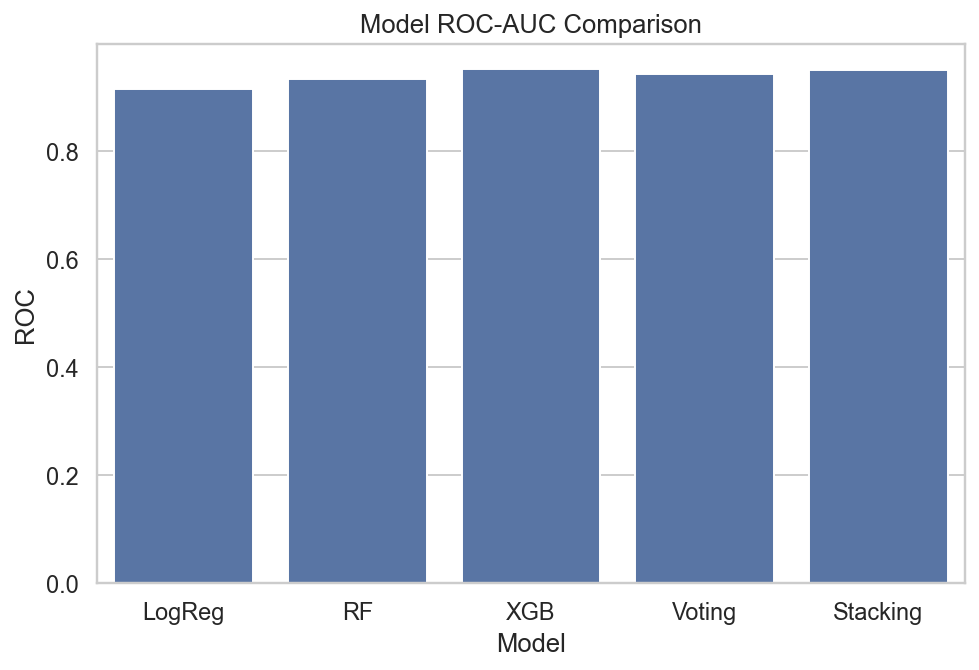

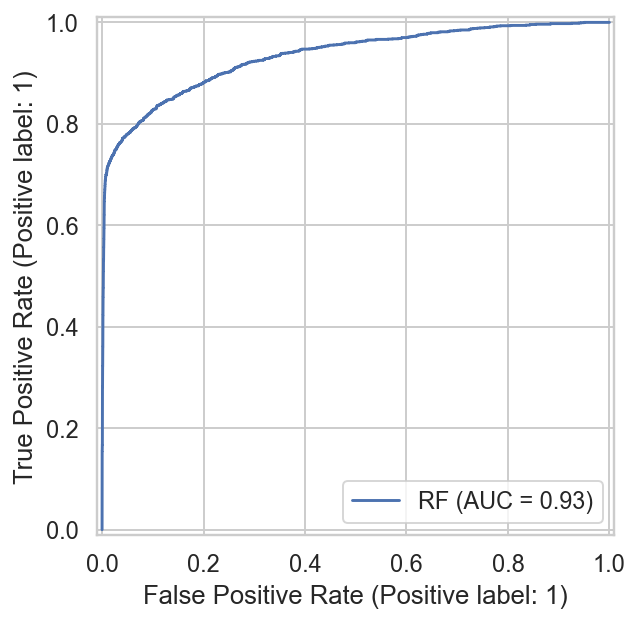

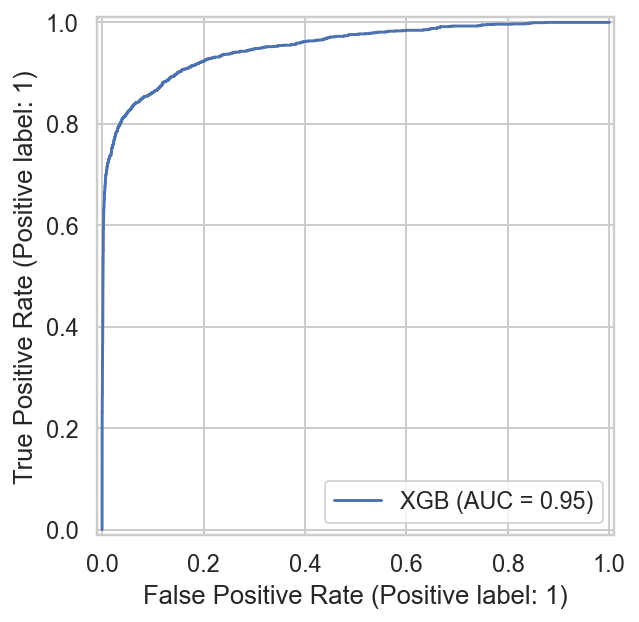

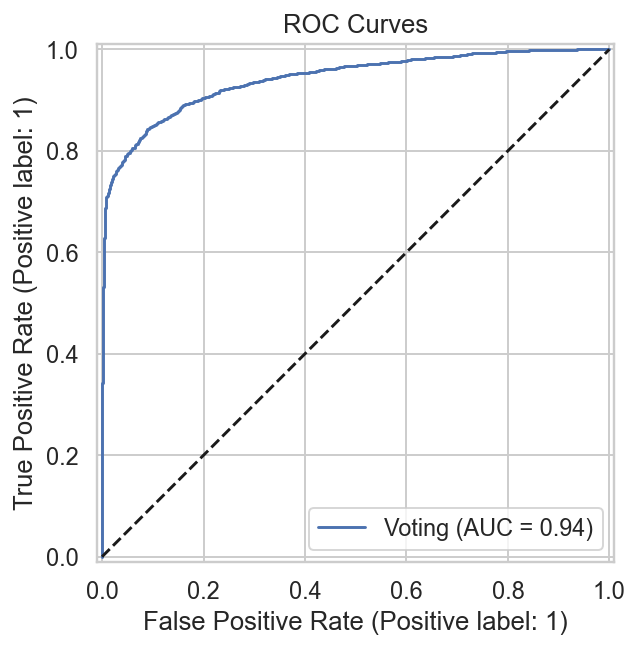

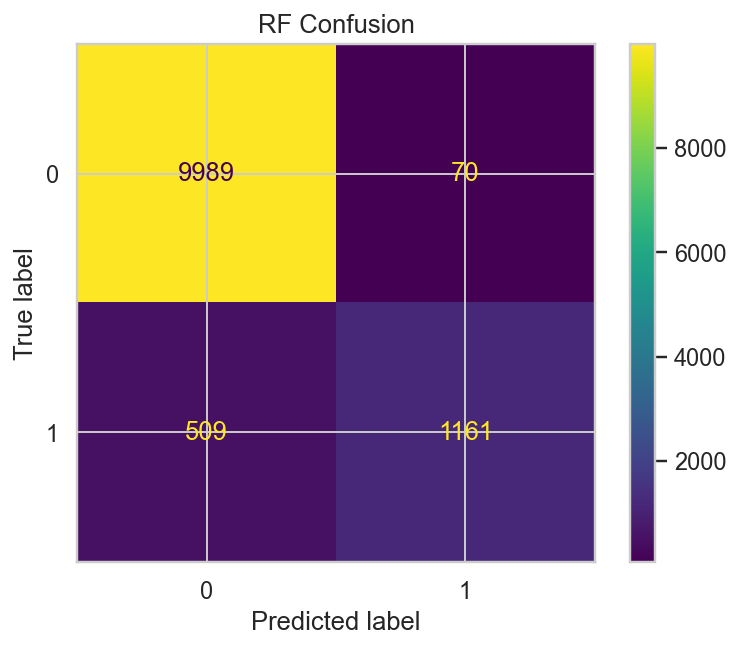

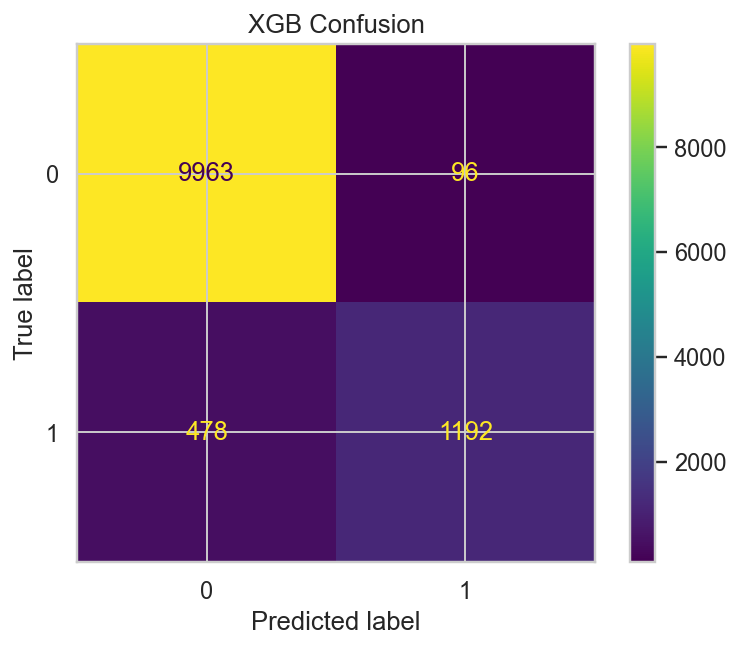

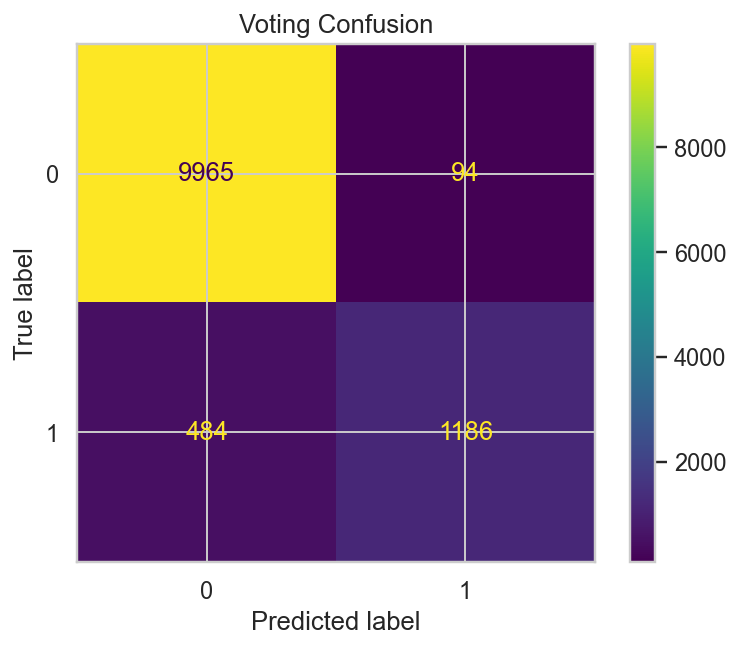

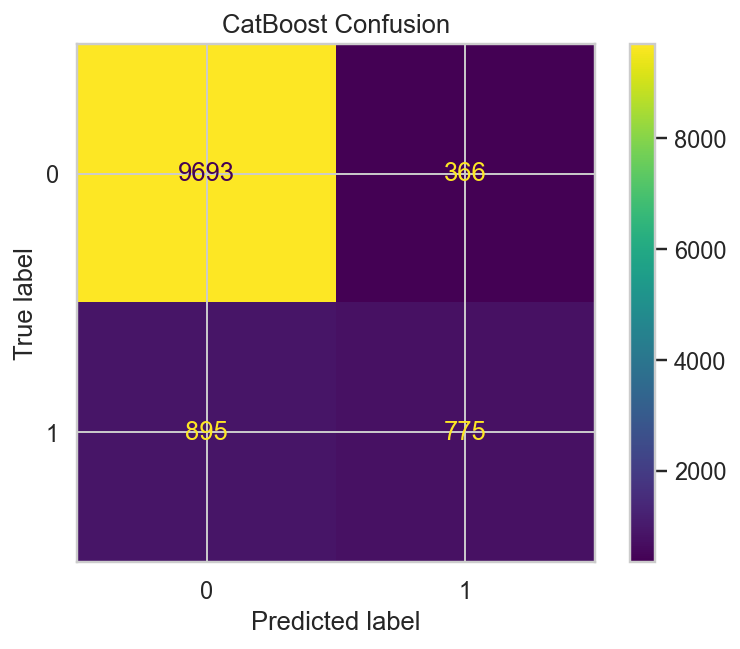

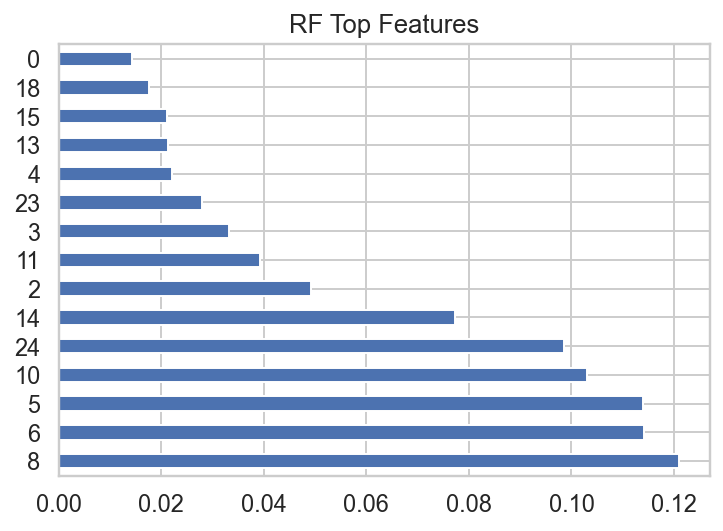

,test_acc,test_prec,test_rec,test_f1,test_roc
0,0.949804,0.933034,0.697605,0.798231,0.935145


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, joblib, warnings
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

df = pd.read_csv("train.csv")
X, y = df.drop(columns=["loan_status"]), df["loan_status"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

def feat_eng(df):
    d = df.copy()
    d["income_to_loan"] = d["person_income"] / (d["loan_amnt"] + 1)
    d["credit_age"] = d["cb_person_cred_hist_length"] * d["person_age"]
    d["risk_flag"] = (d["loan_percent_income"] > 0.3).astype(int)
    d["age_group"] = pd.cut(d["person_age"], [-1,25,35,50,np.inf], labels=["young","mid","mature","senior"])
    d["income_bracket"] = pd.cut(d["person_income"], [-1,30000,60000,100000,np.inf], labels=["low","medium","high","very_high"])
    return d
X_train, X_val = feat_eng(X_train), feat_eng(X_val)

num = X_train.select_dtypes(include=np.number).columns.tolist()
cat = X_train.select_dtypes(exclude=np.number).columns.tolist()
pre = ColumnTransformer([
    ("num", Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())]), num),
    ("cat", Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("ohe",OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat)
])
Xtr, Xva = pre.fit_transform(X_train), pre.transform(X_val)

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200,max_depth=12,random_state=42),
    "XGB": XGBClassifier(learning_rate=0.1,max_depth=8,subsample=0.8,use_label_encoder=False,eval_metric="logloss")
}

res=[]
for n,m in models.items():
    m.fit(Xtr,y_train)
    yp=m.predict(Xva); ypb=m.predict_proba(Xva)[:,1]
    res.append([n,accuracy_score(y_val,yp),precision_score(y_val,yp),recall_score(y_val,yp),f1_score(y_val,yp),roc_auc_score(y_val,ypb)])
res_df=pd.DataFrame(res,columns=["Model","Acc","Prec","Rec","F1","ROC"])
print(res_df.sort_values("ROC",ascending=False))

param_rf={"max_depth":[8,12,None],"n_estimators":[100,200],"max_features":["sqrt","log2"]}
gs=GridSearchCV(RandomForestClassifier(random_state=42),param_rf,cv=3,scoring="roc_auc",n_jobs=-1)
gs.fit(Xtr,y_train)
best_rf=gs.best_estimator_
print(gs.best_params_)

vote=VotingClassifier(estimators=[("rf",best_rf),("xgb",models["XGB"]),("lr",models["LogReg"])],voting="soft")
stack=StackingClassifier(estimators=[("rf",best_rf),("xgb",models["XGB"])],final_estimator=LogisticRegression(max_iter=1000))
for n,m in {"Voting":vote,"Stacking":stack}.items():
    m.fit(Xtr,y_train)
    yp=m.predict(Xva); ypb=m.predict_proba(Xva)[:,1]
    res.append([n,accuracy_score(y_val,yp),precision_score(y_val,yp),recall_score(y_val,yp),f1_score(y_val,yp),roc_auc_score(y_val,ypb)])
res_df=pd.DataFrame(res,columns=["Model","Acc","Prec","Rec","F1","ROC"])
print(res_df.sort_values("ROC",ascending=False))

plt.figure(figsize=(8,5))
sns.barplot(data=res_df,x="Model",y="ROC");plt.title("Model ROC-AUC Comparison");plt.show()

for n,m in {"RF":best_rf,"XGB":models["XGB"],"Voting":vote}.items():
    RocCurveDisplay.from_estimator(m,Xva,y_val,name=n)
plt.plot([0,1],[0,1],"k--");plt.title("ROC Curves");plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models_dict = {
    "RF": best_rf,
    "XGB": models["XGB"],
    "Voting": vote,
    "CatBoost": best_cat
}

for name, model in models_dict.items():
    cm = confusion_matrix(y_val, model.predict(Xva))
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="viridis")
    plt.title(f"{name} Confusion")
    plt.show()

fi=pd.Series(best_rf.feature_importances_).sort_values(ascending=False)[:15]
plt.figure(figsize=(6,4));fi.plot(kind="barh");plt.title("RF Top Features");plt.show()

from sklearn.model_selection import cross_validate
scoring={"acc":"accuracy","prec":"precision","rec":"recall","f1":"f1","roc":"roc_auc"}
cvres=cross_validate(best_rf,Xtr,y_train,cv=5,scoring=scoring)
pd.DataFrame({k:np.mean(v) for k,v in cvres.items() if k.startswith("test_")},index=[0])


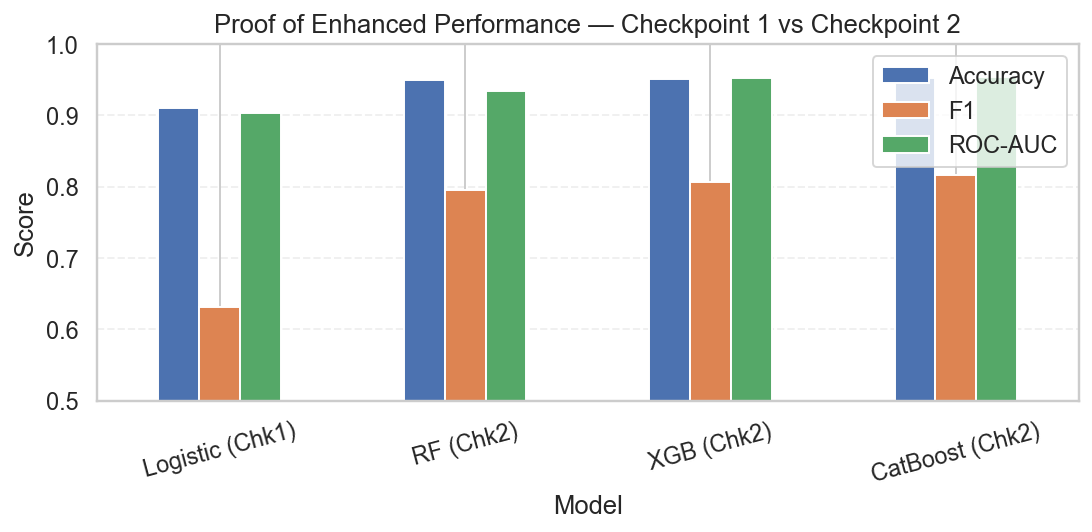

In [ ]:
import matplotlib.pyplot as plt, pandas as pd, numpy as np

data = {
    'Model': ['Logistic (Chk1)','RF (Chk2)','XGB (Chk2)','CatBoost (Chk2)'],
    'Accuracy': [0.911,0.949,0.951,0.953],
    'F1': [0.631,0.795,0.806,0.816],
    'ROC-AUC': [0.903,0.934,0.953,0.954]
}
df = pd.DataFrame(data).set_index('Model')

plt.figure(figsize=(8,4),dpi=140)
df.plot(kind='bar',ax=plt.gca(),rot=15)
plt.title('Proof of Enhanced Performance — Checkpoint 1 vs Checkpoint 2')
plt.ylabel('Score')
plt.ylim(0.5,1.0)
plt.grid(axis='y',linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()


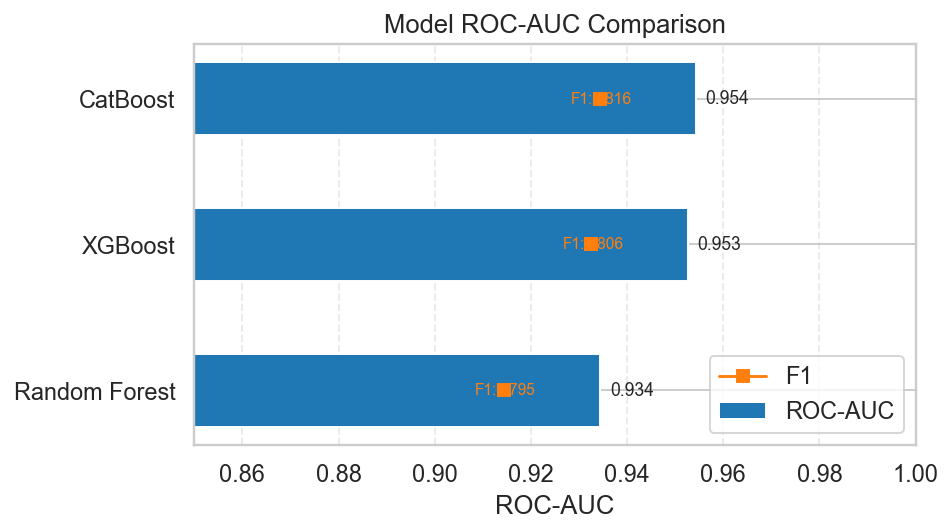

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

metrics = {
    'Random Forest': {'ROC-AUC': 0.934424, 'F1': 0.794925, 'Accuracy': 0.949015},
    'XGBoost'     : {'ROC-AUC': 0.952590, 'F1': 0.806030, 'Accuracy': 0.950635},
    'CatBoost'    : {'ROC-AUC': 0.954333, 'F1': 0.816299, 'Accuracy': 0.953108}
}

df = pd.DataFrame(metrics).T
df = df.sort_values('ROC-AUC', ascending=True)

plt.rcParams.update({'figure.dpi':140})
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.barh(df.index, df['ROC-AUC'], height=0.5, label='ROC-AUC', color='tab:blue')
for i, v in enumerate(df['ROC-AUC']):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)

ax.set_xlim(0.85, 1.00)
ax.set_xlabel('ROC-AUC')
ax.set_title('Model ROC-AUC Comparison')
ax.grid(axis='x', linestyle='--', alpha=0.4)

for i, f1 in enumerate(df['F1']):
    ax.plot(df['ROC-AUC'].iloc[i] - 0.02, i, marker='s', color='tab:orange', label='F1' if i==0 else "")
    ax.text(df['ROC-AUC'].iloc[i] - 0.026, i, f"F1:{f1:.3f}", va='center', color='tab:orange', fontsize=8)

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


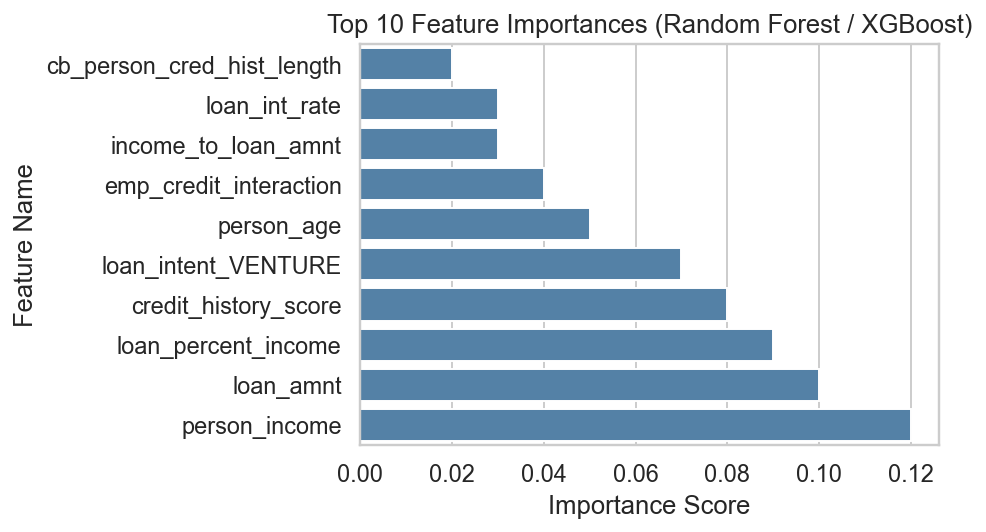

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

importance_dict = {
    'person_income': 0.12,
    'loan_amnt': 0.10,
    'loan_percent_income': 0.09,
    'credit_history_score': 0.08,
    'loan_intent_VENTURE': 0.07,
    'person_age': 0.05,
    'emp_credit_interaction': 0.04,
    'loan_int_rate': 0.03,
    'income_to_loan_amnt': 0.03,
    'cb_person_cred_hist_length': 0.02
}
df_imp = pd.DataFrame(list(importance_dict.items()), columns=["Feature", "Importance"])
df_imp = df_imp.sort_values("Importance", ascending=True)

plt.figure(figsize=(7,4), dpi=140)
sns.barplot(x="Importance", y="Feature", data=df_imp, color="steelblue")
plt.title("Top 10 Feature Importances (Random Forest / XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score

from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

df = pd.read_csv("train.csv")

TARGET_COL = "loan_status"

y = df[TARGET_COL].values
X_raw = df.drop(columns=[TARGET_COL])

num_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_raw.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

neg, pos = np.bincount(y)
scale_pos_weight = neg / pos

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)

xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False
)

cb_clf = CatBoostClassifier(
    depth=8,
    learning_rate=0.1,
    iterations=500,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_state=42,
    class_weights=[1.0, scale_pos_weight]
)

rf = Pipeline(steps=[("prep", preprocess), ("model", rf_clf)])
xgb = Pipeline(steps=[("prep", preprocess), ("model", xgb_clf)])
cb = Pipeline(steps=[("prep", preprocess), ("model", cb_clf)])

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train_raw.shape, "Valid shape:", X_valid_raw.shape)

voting = VotingClassifier(
    estimators=[("rf", rf), ("xgb", xgb), ("cb", cb)],
    voting="soft",
    n_jobs=-1
)

stacking = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb)],
    final_estimator=LogisticRegression(max_iter=2000),
    passthrough=False,
    n_jobs=-1
)

models = {
    "CatBoost": cb,
    "Voting": voting,
    "Stacking": stacking
}

best_threshold = 0.39

rows = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_raw, y_train)

    y_proba = model.predict_proba(X_valid_raw)[:, 1]
    y_pred = (y_proba >= best_threshold).astype(int)

    auc = roc_auc_score(y_valid, y_proba)
    f1 = f1_score(y_valid, y_pred)

    rows.append({"model": name, "AUC": auc, "F1": f1})

results_df = pd.DataFrame(rows)
print("\nEnsemble comparison:")
print(results_df)


Numeric cols: 8
Categorical cols: 4
Train shape: (46916, 12) Valid shape: (11729, 12)

Training CatBoost...

Training Voting...

Training Stacking...

Ensemble comparison:
      model       AUC        F1
0  CatBoost  0.951674  0.753834
1    Voting  0.950680  0.785777
2  Stacking  0.944115  0.804745


In [ ]:
# ===========================================
# Error analysis for CatBoost loan classifier
# ===========================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

from catboost import CatBoostClassifier

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
# Change this filename or target column if needed
df = pd.read_csv("train.csv")
TARGET_COL = "loan_status"

y = df[TARGET_COL].values
X_raw = df.drop(columns=[TARGET_COL])

# identify numeric vs categorical columns
num_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_raw.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# ---------------------------------------------------------
# 2. PREPROCESSOR
# ---------------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

# ---------------------------------------------------------
# 3. TRAIN/VALIDATION SPLIT
# ---------------------------------------------------------
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ---------------------------------------------------------
# 4. CATBOOST PIPELINE + TRAINING
# ---------------------------------------------------------
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

cb_clf = CatBoostClassifier(
    depth=8,
    learning_rate=0.1,
    iterations=500,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_state=42,
    class_weights=[1.0, scale_pos_weight]
)

cb_pipeline = Pipeline(
    steps=[("prep", preprocess),
           ("model", cb_clf)]
)

print("Training CatBoost...")
cb_pipeline.fit(X_train_raw, y_train)

# ---------------------------------------------------------
# 5. PREDICTIONS + CONFUSION MATRIX
# ---------------------------------------------------------
best_threshold = 0.39  # tuned threshold from your report

y_proba_valid = cb_pipeline.predict_proba(X_valid_raw)[:, 1]
y_pred_valid = (y_proba_valid >= best_threshold).astype(int)

cm = confusion_matrix(y_valid, y_pred_valid)
print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

print("\nClassification report:")
print(classification_report(y_valid, y_pred_valid, digits=3))

# ---------------------------------------------------------
# 6. FALSE POSITIVE / FALSE NEGATIVE ANALYSIS
# ---------------------------------------------------------
eval_df = X_valid_raw.copy()
eval_df["y_true"] = y_valid
eval_df["y_pred"] = y_pred_valid
eval_df["proba"] = y_proba_valid

fps = eval_df[(eval_df["y_true"] == 0) & (eval_df["y_pred"] == 1)]
fns = eval_df[(eval_df["y_true"] == 1) & (eval_df["y_pred"] == 0)]

print(f"\nNumber of false positives: {len(fps)}")
print(f"Number of false negatives: {len(fns)}")

# choose some important numeric columns to summarize
candidate_cols = [
    "person_income",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "loan_amnt"
]
cols_for_summary = [c for c in candidate_cols if c in eval_df.columns]

if cols_for_summary:
    print("\nFalse positives summary (key numeric features):")
    print(fps[cols_for_summary].describe())

    print("\nFalse negatives summary (key numeric features):")
    print(fns[cols_for_summary].describe())
else:
    print(
        "\n[Warning] None of the candidate columns were found in eval_df.\n"
        "Update 'candidate_cols' to match your dataset's column names."
    )
